# Predicting Whether a Steam Game Is Free

## Summary
This notebook answers a predictive classification question: using observable Steam store metadata, can we predict whether a game is `Free` or `Paid`?

The workflow is fully reproducible. It downloads the raw dataset from the public source, stores the compressed file in `data/raw/`, writes a decompressed copy to `data/`, engineers predictors, trains a logistic regression classifier, and evaluates performance on a held-out test split.


## Introduction
Steam includes both free-to-play and paid games, and the listing metadata for each game contains signals that may be useful for prediction.

### Predictive Question
Can we predict whether a Steam game is `Free` or `Paid` from observed metadata fields (for example: category flags, platform support, release year, and age requirement)?

### Target
- Target variable: `is_free` with two classes (`Free`, `Paid`)

### Predictive framing
- This notebook is strictly predictive.
- Reported patterns are interpreted as predictive signals for classification performance, not as causal effects.


## Methods & Results
### 1) Setup

In [1]:
# ---- Setup ----
required_packages <- c(
  "jsonlite", "tidyverse", "lubridate", "caret",
  "scales", "patchwork", "purrr", "janitor", "pROC", "knitr"
)

missing_packages <- required_packages[
  !vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)
]

if (length(missing_packages) > 0) {
  stop(
    paste(
      "Install missing packages before running:",
      paste(missing_packages, collapse = ", ")
    )
  )
}

invisible(lapply(required_packages, library, character.only = TRUE))

knitr::opts_chunk$set(
  echo = TRUE,
  warning = FALSE,
  message = FALSE,
  fig.width = 10,
  fig.height = 5.5,
  fig.align = "center"
)

theme_set(
  theme_minimal(base_size = 13) +
    theme(
      plot.title = element_text(face = "bold"),
      legend.position = "right"
    )
)

set.seed(123)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()  masks stats::filter()
✖ purrr::flatten() masks jsonlite::flatten()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: 'caret'


The following object is masked from 'package:purrr':

    lift



Attaching package: 'scales'


The following object is masked from 'package:purrr':

    discard


The following object is masked from 'package:readr':

    col_factor



Attaching package: 'janitor'


The following objects are masked from 'package:stats':

    chisq.test, fisher.test


Type 'citat

### 2) Reproducible data download and ingestion
The code below downloads the raw compressed file from the source repository, stores it in `data/raw/`, and writes a decompressed JSON copy to `data/games_sample.json` for local analysis.


In [2]:
# ---- Reproducible data download ----
dataset_file <- "steam_2025_5k-dataset-games_20250831.json.gz"
dataset_urls <- c(
  # Direct binary endpoint (works for Git LFS-backed files)
  "https://media.githubusercontent.com/media/VintageDon/steam-dataset-2025/main/data/01_raw/steam_2025_5k-dataset-games_20250831.json.gz",
  # Fallbacks
  "https://github.com/VintageDon/steam-dataset-2025/raw/main/data/01_raw/steam_2025_5k-dataset-games_20250831.json.gz",
  "https://raw.githubusercontent.com/VintageDon/steam-dataset-2025/main/data/01_raw/steam_2025_5k-dataset-games_20250831.json.gz"
)

project_root <- if (basename(getwd()) == "src") ".." else "."
data_dir <- file.path(project_root, "data")
raw_dir <- file.path(data_dir, "raw")

dir.create(raw_dir, recursive = TRUE, showWarnings = FALSE)

raw_path <- file.path(raw_dir, dataset_file)
json_copy_path <- file.path(data_dir, "games_sample.json")

is_lfs_pointer <- function(path) {
  if (!file.exists(path)) return(FALSE)

  first_line <- tryCatch(
    readLines(path, n = 1, warn = FALSE),
    error = function(e) character(0)
  )

  length(first_line) > 0 &&
    grepl("^version https://git-lfs.github.com/spec/v1", first_line)
}

is_gzip_file <- function(path) {
  if (!file.exists(path)) return(FALSE)

  con <- file(path, "rb")
  on.exit(close(con), add = TRUE)
  sig <- tryCatch(readBin(con, what = "raw", n = 2), error = function(e) raw(0))

  length(sig) == 2 && identical(as.integer(sig), c(31L, 139L))
}

download_valid_dataset <- function(dest_path, urls) {
  for (u in urls) {
    ok <- suppressWarnings(
      tryCatch(
        {
          utils::download.file(u, destfile = dest_path, mode = "wb", quiet = TRUE)
          TRUE
        },
        error = function(e) FALSE
      )
    )

    if (!ok || !file.exists(dest_path)) next

    if (is_lfs_pointer(dest_path)) {
      unlink(dest_path)
      next
    }

    if (is_gzip_file(dest_path)) {
      return(u)
    }

    unlink(dest_path)
  }

  stop(
    paste0(
      "Could not download a valid gzip dataset file. Checked URLs:\n",
      paste(urls, collapse = "\n")
    )
  )
}

if (!file.exists(raw_path) || is_lfs_pointer(raw_path) || !is_gzip_file(raw_path)) {
  source_url <- download_valid_dataset(raw_path, dataset_urls)
} else {
  source_url <- "existing_local_file"
}

needs_refresh <- !file.exists(json_copy_path) ||
  file.info(raw_path)$mtime > file.info(json_copy_path)$mtime ||
  is_lfs_pointer(json_copy_path)

if (needs_refresh) {
  in_con <- gzfile(raw_path, open = "rb")
  out_con <- file(json_copy_path, open = "wb")

  tryCatch(
    {
      repeat {
        chunk <- readBin(in_con, what = "raw", n = 1024 * 1024)
        if (length(chunk) == 0) break
        writeBin(chunk, out_con)
      }
    },
    finally = {
      close(in_con)
      close(out_con)
    }
  )
}

if (is_lfs_pointer(json_copy_path)) {
  unlink(json_copy_path)
  stop("Local JSON copy is a Git LFS pointer, not real data. Re-run this cell.")
}

raw <- jsonlite::fromJSON(json_copy_path, flatten = TRUE)

if (!"games" %in% names(raw)) {
  stop("Expected a top-level `games` field in the downloaded JSON.")
}

df <- raw$games

cat("Dataset source:", source_url, "\n")
cat("Raw compressed path:", normalizePath(raw_path, winslash = "/"), "\n")
cat("Local JSON copy:", normalizePath(json_copy_path, winslash = "/"), "\n")
cat("Rows:", nrow(df), "Columns:", ncol(df), "\n")


Dataset source: existing_local_file 
Raw compressed path: C:/Users/daffa/dsci-310-group-15/data/raw/steam_2025_5k-dataset-games_20250831.json.gz 
Local JSON copy: C:/Users/daffa/dsci-310-group-15/data/games_sample.json 
Rows: 8711 Columns: 137 


### 3) Cleaning and feature engineering

In [3]:
# ---- Cleaning and feature engineering ----
extract_categories <- function(cat_obj) {
  if (is.null(cat_obj) || length(cat_obj) == 0) return(character(0))

  if (is.data.frame(cat_obj) && "description" %in% names(cat_obj)) {
    return(as.character(cat_obj$description))
  }

  if (is.list(cat_obj)) {
    vals <- purrr::map_chr(cat_obj, function(x) {
      if (is.list(x) && "description" %in% names(x)) {
        as.character(x[["description"]])
      } else {
        NA_character_
      }
    })
    return(vals[!is.na(vals)])
  }

  character(0)
}

flat_data <- df |>
  rename(
    game_id = appid,
    game_name = name_from_applist,
    required_age = app_details.data.required_age,
    is_free = app_details.data.is_free,
    game_type = app_details.data.type,
    release_date = app_details.data.release_date.date,
    windows_support = app_details.data.platforms.windows,
    mac_support = app_details.data.platforms.mac,
    linux_support = app_details.data.platforms.linux,
    categories = app_details.data.categories,
    dlc = app_details.data.dlc,
    demos = app_details.data.demos,
    developers = app_details.data.developers,
    publishers = app_details.data.publishers
  ) |>
  mutate(
    is_free = factor(is_free, levels = c(TRUE, FALSE), labels = c("Free", "Paid")),
    required_age = suppressWarnings(as.integer(required_age)),
    game_type = as.factor(game_type),
    release_date_parsed = suppressWarnings(mdy(release_date)),
    release_year = year(release_date_parsed),
    windows_support = as.logical(windows_support),
    mac_support = as.logical(mac_support),
    linux_support = as.logical(linux_support),
    platform_count = as.integer(replace_na(windows_support, FALSE)) +
      as.integer(replace_na(mac_support, FALSE)) +
      as.integer(replace_na(linux_support, FALSE)),
    has_dlc = purrr::map_lgl(dlc, ~ length(.x) > 0),
    has_demo = purrr::map_lgl(demos, ~ length(.x) > 0),
    category_list = purrr::map(categories, extract_categories),
    n_categories = purrr::map_int(category_list, length),
    developer_name = purrr::map_chr(
      developers,
      ~ if (length(.x) > 0) as.character(.x[[1]]) else NA_character_
    ),
    publisher_name = purrr::map_chr(
      publishers,
      ~ if (length(.x) > 0) as.character(.x[[1]]) else NA_character_
    )
  )

all_cats <- flat_data |>
  select(game_id, category_list) |>
  unnest(category_list) |>
  rename(category = category_list)

top_categories <- all_cats |>
  count(category, sort = TRUE) |>
  slice_head(n = 15) |>
  pull(category)

for (cat_name in top_categories) {
  col_name <- paste0("cat_", janitor::make_clean_names(cat_name))
  flat_data[[col_name]] <- purrr::map_lgl(flat_data$category_list, ~ cat_name %in% .x)
}

cat_cols <- grep("^cat_", names(flat_data), value = TRUE)

df_model <- flat_data |>
  transmute(
    game_id,
    game_name,
    is_free,
    required_age = replace_na(required_age, 0L),
    release_year = replace_na(release_year, -1L),
    game_type = fct_explicit_na(game_type, na_level = "unknown"),
    windows_support = replace_na(windows_support, FALSE),
    mac_support = replace_na(mac_support, FALSE),
    linux_support = replace_na(linux_support, FALSE),
    platform_count = replace_na(platform_count, 0L),
    has_dlc = replace_na(has_dlc, FALSE),
    has_demo = replace_na(has_demo, FALSE),
    n_categories = replace_na(n_categories, 0L),
    developer_name,
    publisher_name,
    across(all_of(cat_cols), ~ replace_na(.x, FALSE))
  ) |>
  filter(!is.na(is_free)) |>
  distinct(game_id, .keep_all = TRUE)

cat("Modeling table:", nrow(df_model), "rows x", ncol(df_model), "columns
")

Warning message:
"There was 1 warning in `transmute()`.
ℹ In argument: `game_type = fct_explicit_na(game_type, na_level = "unknown")`.
Caused by warning:
! `fct_explicit_na()` was deprecated in forcats 1.0.0.
ℹ Please use `fct_na_value_to_level()` instead."


Modeling table: 7967 rows x 30 columns


### 4) Predictor and class visual checks
The plots below are formatted to avoid severe readability problems (clear axis labels, readable text sizing, and legends where class color is used).


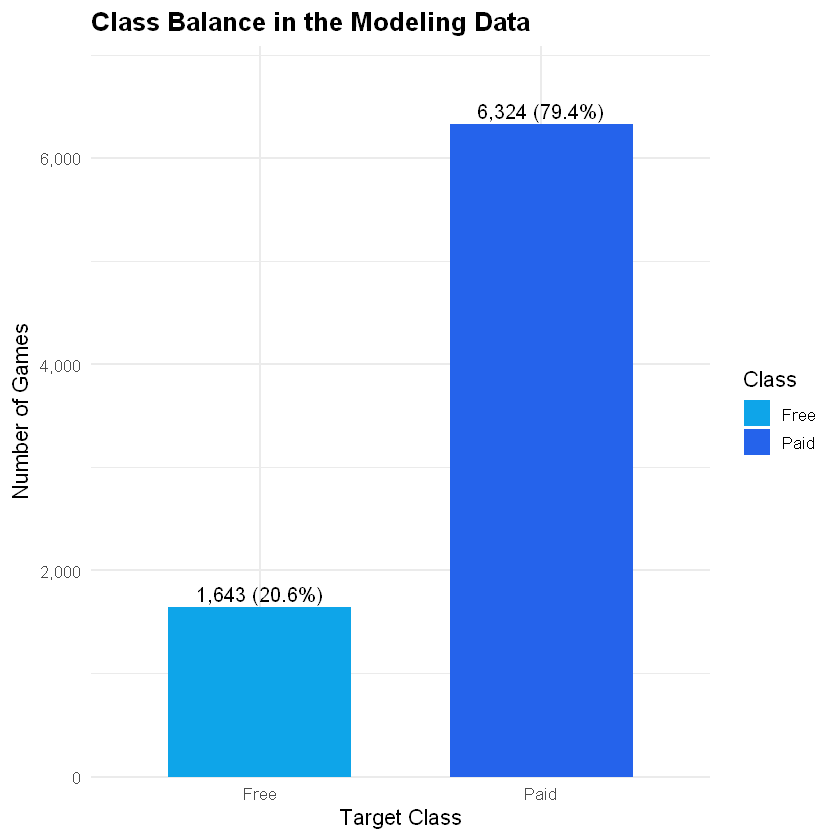

In [4]:
# ---- Class balance ----
class_counts <- df_model |>
  count(is_free) |>
  mutate(
    pct = n / sum(n),
    label = paste0(scales::comma(n), " (", scales::percent(pct, accuracy = 0.1), ")")
  )

ggplot(class_counts, aes(x = is_free, y = n, fill = is_free)) +
  geom_col(width = 0.65) +
  geom_text(aes(label = label), vjust = -0.4, size = 4.2) +
  scale_fill_manual(values = c("Free" = "#0EA5E9", "Paid" = "#2563EB")) +
  scale_y_continuous(labels = scales::comma, expand = expansion(mult = c(0, 0.12))) +
  labs(
    title = "Class Balance in the Modeling Data",
    x = "Target Class",
    y = "Number of Games",
    fill = "Class"
  )

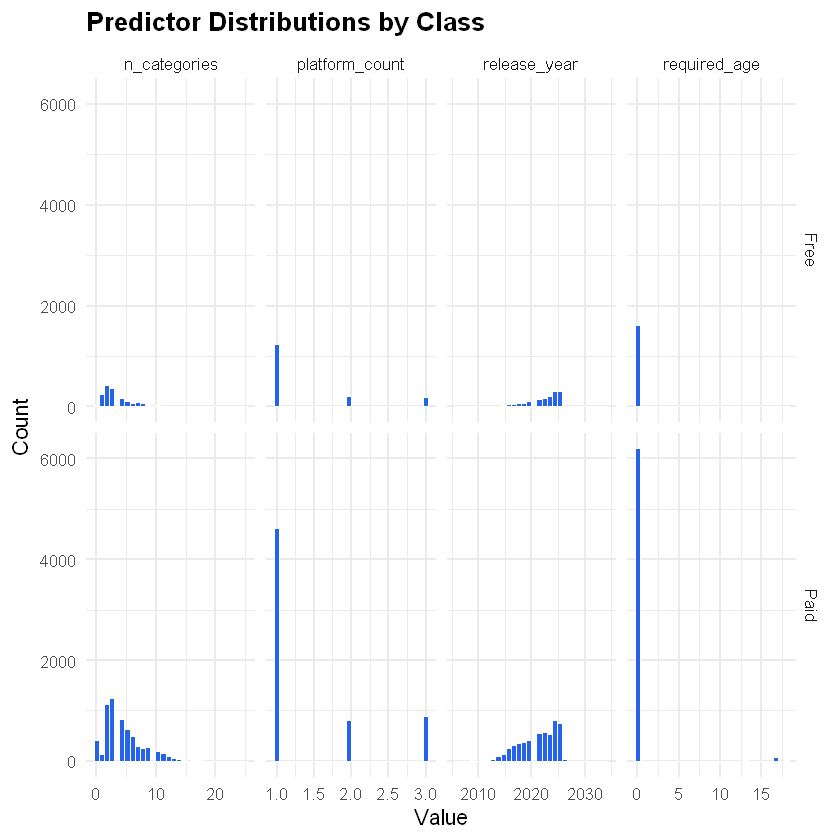

In [5]:
# ---- Numeric predictor distributions ----
numeric_long <- df_model |>
  select(is_free, required_age, release_year, platform_count, n_categories) |>
  pivot_longer(
    cols = -is_free,
    names_to = "predictor",
    values_to = "value"
  ) |>
  filter(!(predictor == "release_year" & value <= 0))

ggplot(numeric_long, aes(x = value)) +
  geom_histogram(bins = 30, fill = "#2563EB", color = "white", linewidth = 0.25) +
  facet_grid(is_free ~ predictor, scales = "free_x") +
  labs(
    title = "Predictor Distributions by Class",
    x = "Value",
    y = "Count"
  )

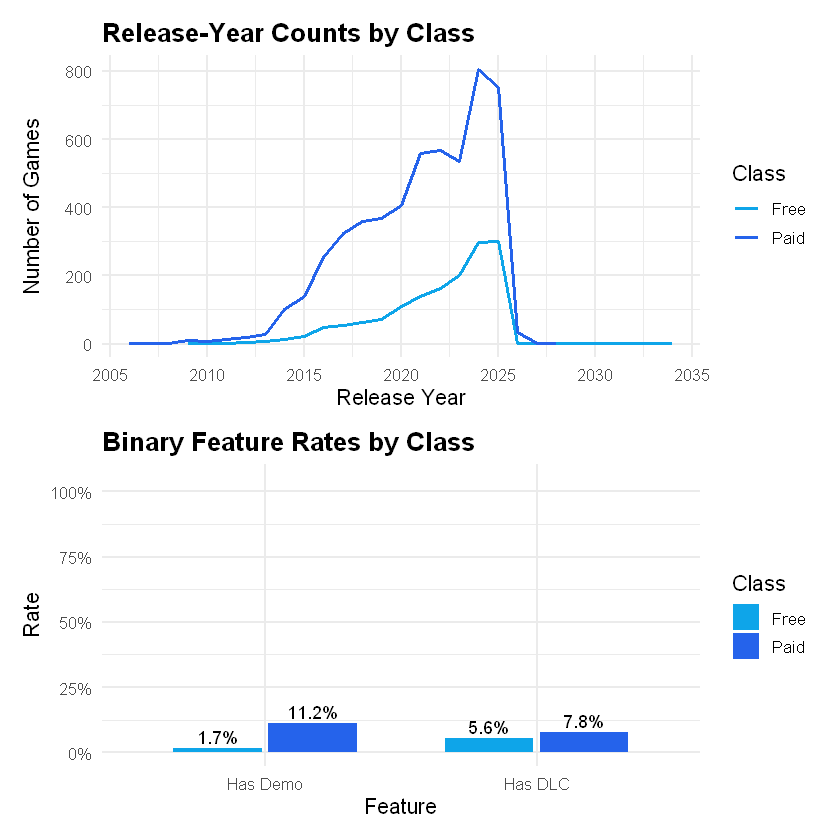

In [6]:
# ---- Additional predictor summaries ----
release_by_class <- df_model |>
  filter(release_year > 0) |>
  count(release_year, is_free)

p_release <- ggplot(release_by_class, aes(x = release_year, y = n, color = is_free)) +
  geom_line(linewidth = 1) +
  scale_color_manual(values = c("Free" = "#0EA5E9", "Paid" = "#2563EB")) +
  labs(
    title = "Release-Year Counts by Class",
    x = "Release Year",
    y = "Number of Games",
    color = "Class"
  )

binary_rates <- df_model |>
  group_by(is_free) |>
  summarise(
    `Has DLC` = mean(has_dlc),
    `Has Demo` = mean(has_demo),
    .groups = "drop"
  ) |>
  pivot_longer(cols = -is_free, names_to = "feature", values_to = "rate")

p_binary <- ggplot(binary_rates, aes(x = feature, y = rate, fill = is_free)) +
  geom_col(position = position_dodge(width = 0.7), width = 0.65) +
  geom_text(
    aes(label = scales::percent(rate, accuracy = 0.1)),
    position = position_dodge(width = 0.7),
    vjust = -0.35,
    size = 3.8
  ) +
  scale_fill_manual(values = c("Free" = "#0EA5E9", "Paid" = "#2563EB")) +
  scale_y_continuous(labels = scales::percent, limits = c(0, 1.05)) +
  labs(
    title = "Binary Feature Rates by Class",
    x = "Feature",
    y = "Rate",
    fill = "Class"
  )

p_release / p_binary

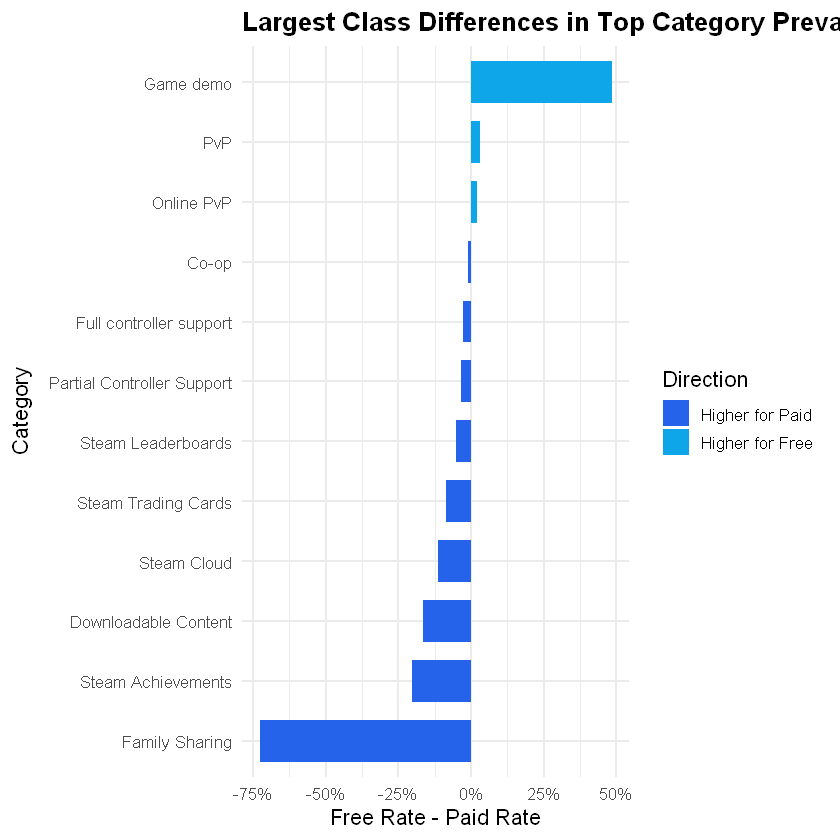

In [7]:
# ---- Category-level predictive signals ----
cat_prev <- flat_data |>
  select(game_id, is_free, category_list) |>
  unnest(category_list) |>
  rename(category = category_list) |>
  filter(category %in% top_categories) |>
  count(is_free, category) |>
  left_join(df_model |> count(is_free, name = "class_total"), by = "is_free") |>
  mutate(rate = n / class_total)

cat_gap <- cat_prev |>
  select(is_free, category, rate) |>
  pivot_wider(names_from = is_free, values_from = rate, values_fill = 0) |>
  mutate(diff_free_minus_paid = Free - Paid) |>
  arrange(desc(abs(diff_free_minus_paid)))

ggplot(
  cat_gap |> slice_head(n = 12),
  aes(
    x = reorder(category, diff_free_minus_paid),
    y = diff_free_minus_paid,
    fill = diff_free_minus_paid > 0
  )
) +
  geom_col(width = 0.7) +
  coord_flip() +
  scale_fill_manual(
    values = c("TRUE" = "#0EA5E9", "FALSE" = "#2563EB"),
    labels = c("FALSE" = "Higher for Paid", "TRUE" = "Higher for Free"),
    name = "Direction"
  ) +
  scale_y_continuous(labels = scales::percent) +
  labs(
    title = "Largest Class Differences in Top Category Prevalence",
    x = "Category",
    y = "Free Rate - Paid Rate"
  )

### 5) Model training and held-out evaluation

In [8]:
# ---- Train/test split and logistic model ----
set.seed(123)
train_idx <- createDataPartition(df_model$is_free, p = 0.80, list = FALSE)
train_df <- df_model[train_idx, ]
test_df <- df_model[-train_idx, ]

predictor_names <- c(
  "required_age", "release_year", "game_type",
  "windows_support", "mac_support", "linux_support",
  "platform_count", "has_dlc", "has_demo", "n_categories",
  grep("^cat_", names(df_model), value = TRUE)
)

train_model <- train_df |>
  select(is_free, all_of(predictor_names))

test_model <- test_df |>
  select(is_free, all_of(predictor_names))

baseline_class <- train_model |>
  count(is_free, sort = TRUE) |>
  slice(1) |>
  pull(is_free) |>
  as.character()

baseline_pred <- factor(
  rep(baseline_class, nrow(test_model)),
  levels = levels(test_model$is_free)
)

baseline_cm <- confusionMatrix(baseline_pred, test_model$is_free, positive = "Free")
baseline_accuracy <- unname(baseline_cm$overall["Accuracy"])

ctrl <- trainControl(
  method = "cv",
  number = 5,
  classProbs = TRUE,
  summaryFunction = twoClassSummary
)

model_formula <- as.formula(
  paste("is_free ~", paste(predictor_names, collapse = " + "))
)

set.seed(123)
fit_glm <- caret::train(
  model_formula,
  data = train_model,
  method = "glm",
  family = binomial(),
  metric = "ROC",
  trControl = ctrl
)

prob_free <- predict(fit_glm, newdata = test_model, type = "prob")$Free
pred_class <- factor(
  ifelse(prob_free >= 0.5, "Free", "Paid"),
  levels = levels(test_model$is_free)
)

cm <- confusionMatrix(pred_class, test_model$is_free, positive = "Free")
roc_obj <- pROC::roc(
  response = test_model$is_free,
  predictor = prob_free,
  levels = c("Paid", "Free"),
  direction = "<"
)

eval_tbl <- tibble(
  metric = c(
    "Baseline accuracy (majority class)",
    "Model accuracy",
    "Sensitivity (Free recall)",
    "Specificity (Paid recall)",
    "Balanced accuracy",
    "ROC AUC"
  ),
  value = c(
    baseline_accuracy,
    unname(cm$overall["Accuracy"]),
    unname(cm$byClass["Sensitivity"]),
    unname(cm$byClass["Specificity"]),
    unname(cm$byClass["Balanced Accuracy"]),
    as.numeric(pROC::auc(roc_obj))
  )
)

eval_tbl |>
  mutate(value = round(value, 4))

metric,value
<chr>,<dbl>
Baseline accuracy (majority class),0.7940
Model accuracy,0.9585
Sensitivity (Free recall),0.8323
Specificity (Paid recall),0.9913
Balanced accuracy,0.9118
ROC AUC,0.9232


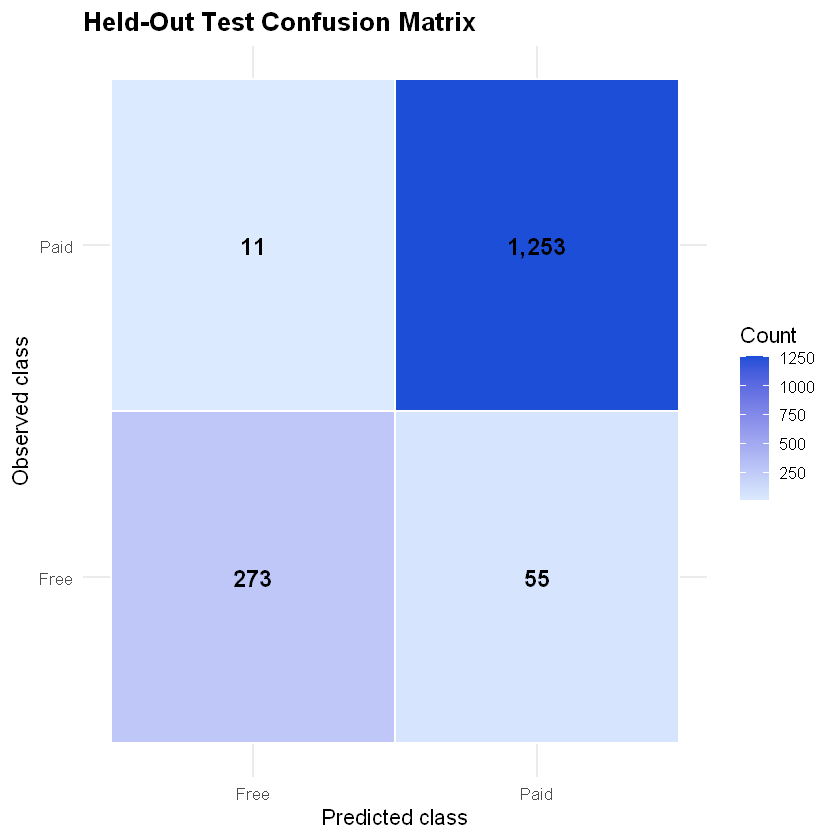

In [9]:
# ---- Confusion matrix plot ----
cm_df <- as.data.frame(cm$table)

ggplot(cm_df, aes(x = Prediction, y = Reference, fill = Freq)) +
  geom_tile(color = "white", linewidth = 0.8) +
  geom_text(aes(label = scales::comma(Freq)), size = 5, fontface = "bold") +
  scale_fill_gradient(low = "#DBEAFE", high = "#1D4ED8") +
  labs(
    title = "Held-Out Test Confusion Matrix",
    x = "Predicted class",
    y = "Observed class",
    fill = "Count"
  )

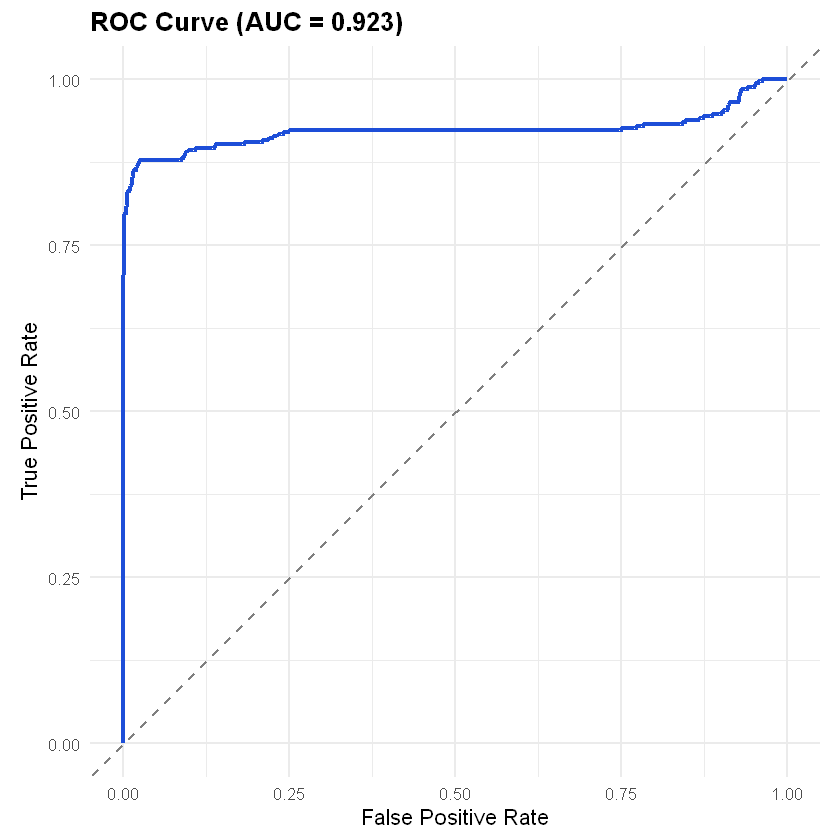

In [10]:
# ---- ROC curve ----
roc_df <- tibble(
  tpr = rev(roc_obj$sensitivities),
  fpr = rev(1 - roc_obj$specificities)
)

ggplot(roc_df, aes(x = fpr, y = tpr)) +
  geom_line(color = "#1D4ED8", linewidth = 1.2) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray50") +
  coord_equal() +
  labs(
    title = paste0("ROC Curve (AUC = ", round(as.numeric(pROC::auc(roc_obj)), 3), ")"),
    x = "False Positive Rate",
    y = "True Positive Rate"
  )

In [11]:
# ---- Highest-magnitude logistic coefficients ----
coef_tbl <- summary(fit_glm$finalModel)$coefficients |>
  as.data.frame() |>
  rownames_to_column("term") |>
  as_tibble() |>
  mutate(
    odds_ratio = exp(Estimate),
    abs_estimate = abs(Estimate)
  ) |>
  filter(term != "(Intercept)") |>
  arrange(desc(abs_estimate))

coef_tbl |>
  select(term, Estimate, odds_ratio, `Pr(>|z|)`) |>
  slice_head(n = 12)

term,Estimate,odds_ratio,Pr(>|z|)
<chr>,<dbl>,<dbl>,<dbl>
game_typeseries,-39.319605,8.389046e-18,9.951841e-01
game_typedemo,-32.975973,4.772182e-15,9.943034e-01
game_typemod,-31.919147,1.373063e-14,9.953210e-01
windows_supportTRUE,-16.680544,5.698121e-08,9.968465e-01
cat_downloadable_contentTRUE,-15.743508,1.454392e-07,9.942093e-01
game_typegame,-14.861085,3.514898e-07,9.974291e-01
game_typeepisode,-14.687856,4.179699e-07,9.974591e-01
game_typevideo,-13.541796,1.314840e-06,9.976573e-01
game_typemusic,-12.581172,3.436106e-06,9.978235e-01


## Discussion
This notebook answers a predictive question and reports predictive performance only.

Key takeaways from the held-out evaluation:
- The logistic model outperforms the majority-class baseline on the test split.
- The ROC AUC and balanced accuracy indicate meaningful predictive signal.
- The confusion matrix shows remaining class-specific errors, so threshold tuning may be useful for class-priority use cases.

Interpretation scope:
- Coefficients and category prevalence gaps are used here as predictive indicators.
- These results should not be interpreted as causal explanations for why games are free or paid.

Limitations for prediction:
- Class imbalance can bias decisions toward the majority class.
- The dataset is a snapshot, so predictive performance may shift over time as market patterns change.

Possible next predictive steps:
1. Compare regularized logistic regression and tree-based models on the same split.
2. Tune classification thresholds for precision-recall tradeoffs tied to the deployment goal.
3. Add probability calibration checks to improve the reliability of predicted probabilities.


## References
- Fountain, D. (2025). *Steam Dataset 2025: Multi-Modal Gaming Analytics Platform* (Version 1.0.0). Zenodo. https://doi.org/10.5281/zenodo.17286923
- VintageDon. (2025). *steam-dataset-2025* (GitHub repository). https://github.com/VintageDon/steam-dataset-2025
- Raw sample used in this notebook: https://raw.githubusercontent.com/VintageDon/steam-dataset-2025/main/data/01_raw/steam_2025_5k-dataset-games_20250831.json.gz
- Kuhn, M. (2008). Building Predictive Models in R Using the caret Package. *Journal of Statistical Software, 28*(5).
- Robin, X., et al. (2011). pROC: an open-source package for R and S+ to analyze and compare ROC curves. *BMC Bioinformatics, 12*(77).
